Cell 1 — Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

Cell 2 — Enter your data

In [3]:
questions = {

    "Do you think the world's climate is changing?":
    {
        "labels": [
            "Definitely\nchanging",
            "Probably\nchanging",
            "Not sure/\nNo opinion",
            "Probably\nnot\nchanging",
            "Definitely\nnot\nchanging"
        ],
        "freq": [497, 283, 48, 45, 171]
    },

    "How important is the issue of global warming to you personally?":
    {
        "labels": [
            "Extremely\nimportant",
            "Very\nimportant",
            "Somewhat\nimportant",
            "Not too\nimportant",
            "Not at all\nimportant"
        ],
        "freq": [295, 281, 268, 125, 75]
    },

    "How worried are you about global warming?":
    {
        "labels": [
            "Very\nworried",
            "Somewhat\nworried",
            "Not very\nworried",
            "Not at all\nworried"
        ],
        "freq": [304, 430, 200, 110]
    },

    "How much do you think global warming will harm you personally?":
    {
        "labels": [
            "A great\ndeal",
            "A moderate\namount",
            "Only a\nlittle",
            "Not at\nall",
            "Don't\nknow"
        ],
        "freq": [217, 360, 261, 143, 63]
    },

    "How much do you think global warming will harm future generations?":
    {
        "labels": [
            "A great\ndeal",
            "A moderate\namount",
            "Only a\nlittle",
            "Not at\nall",
            "Don't\nknow"
        ],
        "freq": [456, 280, 160, 87, 61]
    },

    "Do you favor increasing taxes on fossil fuels to reduce climate change?":
    {
        "labels": [
            "Strongly\nfavor",
            "Somewhat\nfavor",
            "Neither\nfavor\nnor Against",
            "Somewhat\nagainst",
            "strongly\ndisagree"
        ],
        "freq": [211, 287, 261, 139, 146]
    }
}

Cell 3 — Figure and publication settings

In [4]:
# Elsevier single-column width
FIG_WIDTH = 90 / 25.4

# Figure height
FIG_HEIGHT = 6.6

# TIFF resolution
DPI = 1200

# Panel letters
letters = ["(A)", "(B)", "(C)", "(D)", "(E)", "(F)"]

Cell 4 — Matplotlib/Seaborn styling

In [5]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({

    "font.family": "Times New Roman",
    "font.size": 6.5,

    "axes.titlesize": 7,
    "axes.titleweight": "bold",

    "axes.labelsize": 6.5,

    "xtick.labelsize": 5,
    "ytick.labelsize": 5.5,

    "axes.linewidth": 0.7,

    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

Cell 5 — Colors and create the figure

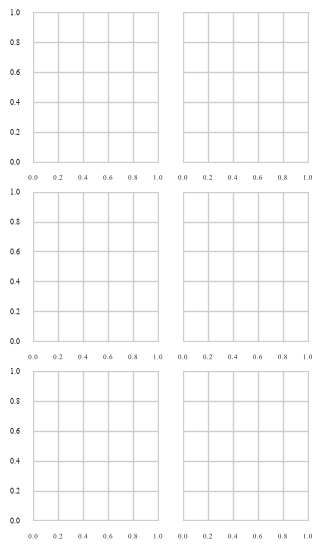

In [6]:
colors = sns.color_palette("Set2", 6)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharey=True
)

axes = axes.flatten()

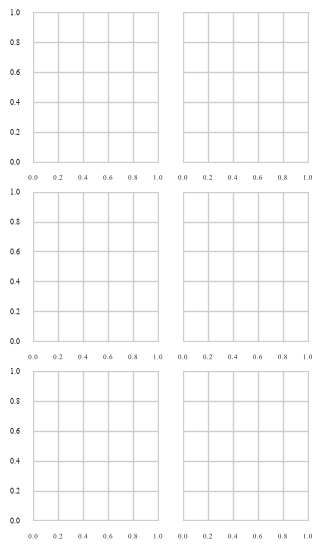

In [7]:
fig

Cell 6 — Create the six panels

In [8]:
for i, (question, data) in enumerate(questions.items()):

    ax = axes[i]

    # Bar positions
    x = list(range(len(data["freq"])))

    # Bars
    bars = ax.bar(
        x,
        data["freq"],
        color=colors[i],
        edgecolor="black",
        linewidth=0.5,
        width=0.70,
        zorder=3
    )

    # X-axis
    ax.set_xticks(x)

    ax.set_xticklabels(
        data["labels"],
        rotation=0,
        ha="center",
        va="top",
        fontsize=5,
        linespacing=0.85
    )

    ax.set_xlim(
        -0.55,
        len(x) - 0.45
    )

    # Title
    title = textwrap.fill(
        question,
        width=28
    )

    ax.set_title(
        f"{letters[i]} {title}",
        fontsize=7,
        fontweight="bold",
        pad=4,
        loc="center"
    )

    # Y-axis
    ax.set_ylabel(
        "Frequency",
        fontsize=6.5,
        fontweight="normal",
        labelpad=2
    )

    # Hide numerical y-axis labels
    ax.tick_params(
        axis="y",
        which="both",
        labelleft=False,
        length=0
    )

    # Y-axis range
    ax.set_ylim(0, 550)

    # Gridline positions
    ax.set_yticks([
        0,
        100,
        200,
        300,
        400,
        500
    ])

    # Frequency labels
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 8,
            str(int(height)),
            ha="center",
            va="bottom",
            fontsize=5.5,
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                boxstyle="round,pad=0.08"
            ),
            zorder=5
        )

    # Horizontal grid
    ax.grid(
        axis="y",
        color="0.85",
        linewidth=0.4,
        alpha=0.8,
        zorder=0
    )

    # Remove vertical grid
    ax.grid(
        axis="x",
        visible=False
    )

    # Spines
    for spine in ax.spines.values():

        spine.set_linewidth(0.7)
        spine.set_color("black")

    # X ticks
    ax.tick_params(
        axis="x",
        which="major",
        width=0.6,
        length=2.5,
        pad=2
    )

Cell 7 — Adjust the layout

In [9]:
plt.subplots_adjust(
    left=0.045,
    right=0.985,
    bottom=0.038,
    top=0.94,
    wspace=0.19,
    hspace=0.35
)

plt.show()

<Figure size 640x480 with 0 Axes>

Cell 8 — Save the figure

In [10]:
output_base = (
    "/Users/freebird/Library/CloudStorage/"
    "OneDrive-TexasTechUniversity/VS Code/python/"
    "ClimateChange_Perceptions_90mm"
)

pdf_path = output_base + ".pdf"

tiff_path = output_base + "_1200dpi.tiff"

PDF

In [11]:
fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches=None,
    pad_inches=0,
    facecolor="white",
    edgecolor="white"
)

TimeoutError: [Errno 60] Operation timed out: '/Users/freebird/Library/CloudStorage/OneDrive-TexasTechUniversity/VS Code/python/ClimateChange_Perceptions_90mm.pdf'

TIFF

In [ ]:
fig.savefig(
    tiff_path,
    format="tiff",
    dpi=DPI,
    bbox_inches=None,
    pad_inches=0,
    facecolor="white",
    edgecolor="white"
)

Cell 9 — Verify the output

In [ ]:
print("--------------------------------------------")
print("Climate perception figure created")
print("--------------------------------------------")

print("\nPDF:")
print(pdf_path)

print("\nTIFF:")
print(tiff_path)

print("\n--------------------------------------------")

print(f"Figure width: {FIG_WIDTH:.4f} inches")
print("Figure width: 90.0 mm")

print(f"\nFigure height: {FIG_HEIGHT:.2f} inches")
print(f"Figure height: {FIG_HEIGHT * 25.4:.1f} mm")

print(f"\nTIFF resolution: {DPI} DPI")
print("PDF: Vector format")

print("--------------------------------------------")